# Module 2: Epidemic Modeling Template

## Team Members:
Kaitlyn Cole and Jake Carnell

## Project Title:
Public Health: Modeling the Spread and Impact of a Respiratory Virus in the UVA Student Population

## Project Goal:
The goal of this project is to analyze outbreak data of a mystery virus and use modeling to understand how the virus spreads through University of Virginia’s (UVA) student population. Additionally, taking this data and information and comparing it to other viruses to determine what our mystery virus is most likely to be. We aimed to estimate the initial growth rate, predict the epidemic peak, and evaluate potential intervention strategies using a SEIR (Susceptible-Exposed-Infected-Recovered) model.

## 1. Data and disease background
* Prevalence & incidence in the UVA population
  * Prevalence is the total number of active infections in the student population at a given time, while incidence is the number of new infections over a specific period of time. In the context of this problem we know the incidence due to the active data drop but are not able to determine the prevalence of this specific virus. By using our data set of active cases, we were able to observe how prevalence rapidly increased during the early stages of outbreak due to exponential growth in infections, however, we cannot provide an exact and accurate number.
* Economic burden (you can generalize from respiratory viruses)
  * Respiratory viruses can cause significant economic burden in university settings. For students, the most prevalent cost in this case is healthcare costs such as hospital visit, testing, and treatments. There are also other costs such as future intervention costs for vaccinations. Additionally, missed classes and reduced academic productivity due to illness can be seen as a waste of tuition costs. 
* Symptoms
  * 
* Biological mechanisms (anatomy, organ physiology, cell & molecular physiology - you can generalize from viral biology)
  *


## 2. Data Analysis
This section should be filled out sequentially as a full report of the work you've done over this module. You can copy and paste code from any main.py file here, and run it to produce plots. Once you gain more information throughout the module, you do not need to go back and "fix" earlier results. In other words, if your early predictions are found to be wrong when gaining new data, do not go back and rewrite them.

### 2a. Methods

*IN A SUMMARY, DESCRIBE THE METHODS YOU USED TO ANALYZE AND MODEL THE DATA.*


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #1</b> 

</div>



### 2b. Plot the data & estimate initial growth rate (R0) from early data (through day 45)

##### 2b.1 Importing Graphing and Mathmatical Functions

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

##### 2b.2 Plotting Data and Finding R0

Fitted I0 = 1.2063151589430112
Fitted growth rate r = 0.11982506453515594


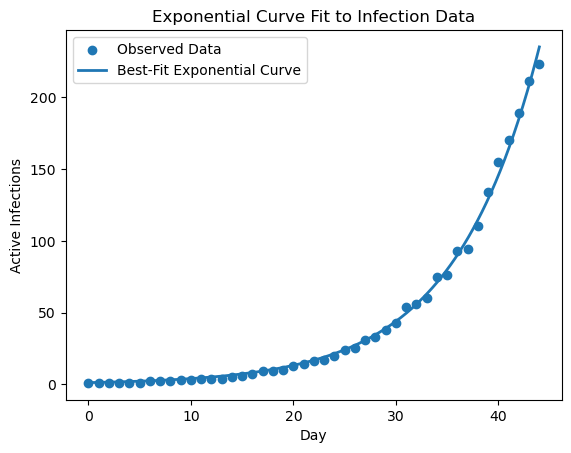

Estimated R0 = 1.239650129070312


In [12]:
data = pd.read_csv('/Users/vkb5cq/Desktop/Spring 2026/BME 2315/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#1.csv', parse_dates=['date'], header=0, index_col=None)

def exponential_growth(t, r):
    return I0 * np.exp(r * t)

data['day'] = (data['date'] - data['date'].min()).dt.days

t = data['day'].to_numpy()
I = data['active reported daily cases'].to_numpy()

def exponential_model(t, I0, r):
    return I0 * np.exp(r * t)


params, covariance = curve_fit(exponential_model, t, I, p0=[I[0], 0.2])

I0_fit, r_fit = params

print("Fitted I0 =", I0_fit)
print("Fitted growth rate r =", r_fit)

t_smooth = np.linspace(min(t), max(t), 300)
I_fit = exponential_model(t_smooth, I0_fit, r_fit)

plt.figure()
plt.scatter(t, I, label='Observed Data')
plt.plot(t_smooth, I_fit, linewidth=2, label='Best-Fit Exponential Curve')
plt.xlabel('Day')
plt.ylabel('Active Infections')
plt.title('Exponential Curve Fit to Infection Data')
plt.legend()
plt.show()

D = 2
R0 = 1 + r_fit * D

print("Estimated R0 =", R0)


##### 2b.3 Initial Conclusions
Our R0 value was 1.24. This is the closest to the seasonal influenza virus that had an R0 value of 1.3. This is a respiratory infection that spreads easily between people. The symptoms are fever, cooughing, and sore throat. The best form of prevention is vaccination.
Given the initial information that this is a respiratory disease and the R0 value is close to other known repsiratory diseases, we think this R0 value is accurate. 


<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #2</b> 

</div>



### 2c. Use Euler's method to solve the SEIR model.
##### 2c.1 Loading Data Release 2 

In [13]:
data = pd.read_csv(
'/Users/vkb5cq/Desktop/Spring 2026/BME 2315/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#2.csv',
parse_dates=['date']
)
data['day'] = (data['date'] - data['date'].min()).dt.days

t = data['day'].to_numpy()
I = data['active reported daily cases'].to_numpy()

# Update initial conditions
N = 17900
I0 = I[0]
E0 = I0
R0_init = 0
S0 = N - I0 - E0

##### 2c.2 Create Euler SEIR Function

In [14]:
def euler_SEIR(beta, sigma, gamma):

    S = np.zeros(len(t))
    E = np.zeros(len(t))
    I_model = np.zeros(len(t))
    R = np.zeros(len(t))

    S[0] = S0
    E[0] = E0
    I_model[0] = I0
    R[0] = R0_init

    dt = 1

    for i in range(len(t)-1):

        dS = -beta * S[i] * I_model[i] / N
        dE = beta * S[i] * I_model[i] / N - sigma * E[i]
        dI = sigma * E[i] - gamma * I_model[i]
        dR = gamma * I_model[i]

        S[i+1] = S[i] + dS * dt
        E[i+1] = E[i] + dE * dt
        I_model[i+1] = I_model[i] + dI * dt
        R[i+1] = R[i] + dR * dt

    return S, E, I_model, R

### 2d. Fit the SEIR model to the data by changing beta, gamma, and sigma.
This section should come from your python code after Data Release #2.

In [15]:
beta_range = np.linspace(0.1,1.0,15)
sigma_range = np.linspace(0.1,1.0,15)
gamma_range = np.linspace(0.05,0.5,15)

best_SSE = np.inf
best_beta = None
best_sigma = None
best_gamma = None

for b in beta_range:
    for s in sigma_range:
        for g in gamma_range:

            S,E,I_model,R = euler_SEIR(b,s,g)

            SSE = np.sum((I_model - I)**2)

            if SSE < best_SSE:

                best_SSE = SSE
                best_beta = b
                best_sigma = s
                best_gamma = g


print("Best beta =", best_beta)
print("Best sigma =", best_sigma)
print("Best gamma =", best_gamma)
print("Lowest SSE =", best_SSE)

Best beta = 0.2928571428571429
Best sigma = 0.55
Best gamma = 0.1142857142857143
Lowest SSE = 146701.0718267862


### 2e. Plot the model-predicted infections over time compared to the data.
This section should come from your python code after Data Release #2.

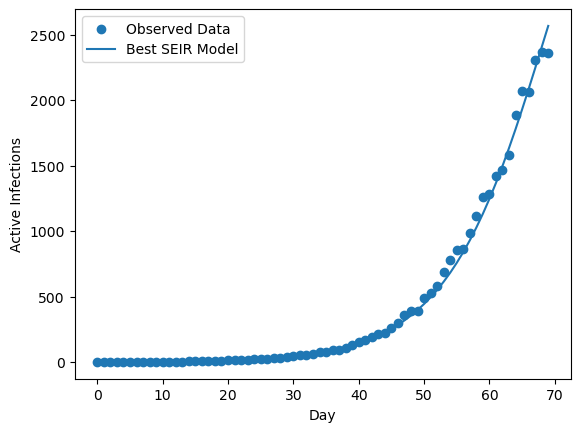

In [16]:
S,E,I_model,R = euler_SEIR(best_beta,best_sigma,best_gamma)

plt.figure()
plt.scatter(t, I, label="Observed Data")
plt.plot(t, I_model, label="Best SEIR Model")
plt.xlabel("Day")
plt.ylabel("Active Infections")
plt.legend()
plt.show()

### 2e. Predict the day and amount of active cases at the peak of the epidemic spread.
This section should come from your python code after Data Release #2.


In [17]:
# Predict future epidemic peak
t = np.arange(0, 200)

# run SEIR model using best parameters
S_future, E_future, I_future, R_future = euler_SEIR(best_beta, best_sigma, best_gamma)

# find epidemic peak
peak_index = np.argmax(I_future)
peak_day = t_future[peak_index]
peak_cases = I_future[peak_index]

print("Predicted peak day:", peak_day)
print("Predicted active cases at peak:", int(peak_cases))

Predicted peak day: 80
Predicted active cases at peak: 3692



<div style="
    border-left: 6px solid #fbc02d;
    background-color: #fff8e1;
    padding: 10px 15px;
    border-radius: 4px;
">
<b style="color:#f57f17;">ANALYSIS AFTER DATA RELEASE #3</b> 

</div>



### 2f. Plot the full dataset (Data Release #3) against your model.
This section should come from your python code after Data Release #3.


True peak day: 82
True peak cases: 3294
Model predicted peak day: 80
Model predicted peak cases: 3692
Percent relative error (cases): 12.102814252470836 %
Percent relative error (day): 2.4390243902439024 %


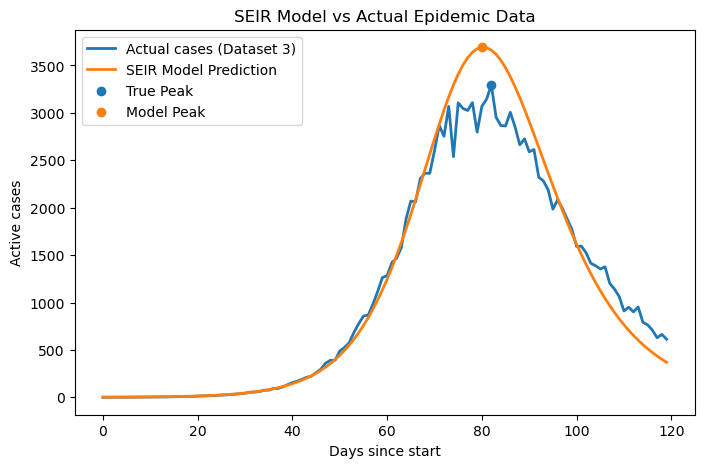

In [19]:
# Load Dataset Release #3
data = pd.read_csv(
'/Users/vkb5cq/Desktop/Spring 2026/BME 2315/Module-2-Epidemics-SIR-Modeling/Data/mystery_virus_daily_active_counts_RELEASE#3.csv', parse_dates=['date'])

data['day'] = (data['date'] - data['date'].min()).dt.days

t = data['day'].to_numpy()
I_actual = data['active reported daily cases'].to_numpy()

# Population and initial values
N = 17900

I0 = I_actual[0]
E0 = I0
R0_init = 0
S0 = N - I0 - E0

# Run SEIR model with best parameters
S_model, E_model, I_model, R_model = euler_SEIR(best_beta, best_sigma, best_gamma)

# Find peaks
true_peak_index = np.argmax(I_actual)
true_peak_day = t[true_peak_index]
true_peak_cases = I_actual[true_peak_index]

model_peak_index = np.argmax(I_model)
model_peak_day = t[model_peak_index]
model_peak_cases = I_model[model_peak_index]

# Percent Relative Error
error_cases = abs(true_peak_cases - model_peak_cases) / true_peak_cases * 100
error_day = abs(true_peak_day - model_peak_day) / true_peak_day * 100

print("True peak day:", true_peak_day)
print("True peak cases:", true_peak_cases)
print("Model predicted peak day:", model_peak_day)
print("Model predicted peak cases:", int(model_peak_cases))
print("Percent relative error (cases):", error_cases, "%")
print("Percent relative error (day):", error_day, "%")

# Plot model vs actual data
plt.figure(figsize=(8,5))
plt.plot(t, I_actual, label="Actual cases (Dataset 3)", linewidth=2)
plt.plot(t, I_model, label="SEIR Model Prediction", linewidth=2)
plt.scatter(true_peak_day, true_peak_cases, label="True Peak")
plt.scatter(model_peak_day, model_peak_cases, label="Model Peak")
plt.xlabel("Days since start")
plt.ylabel("Active cases")
plt.title("SEIR Model vs Actual Epidemic Data")
plt.legend()

plt.show()

### 2g. Intervention strategies for new outbreak at VT (70 days of infection)
#### 2g.1 Setting Up Data For Internventions



In [20]:
N_VT = 37000
I0_VT = 1
R0_VT = 0
E0_VT = I0_VT
S0_VT = N_VT - I0_VT - E0_VT - R0_VT

def euler_SEIR_custom(beta, sigma, gamma, t_arr, N_pop, S_init, E_init, I_init, R_init):
    S = np.zeros(len(t_arr))
    E = np.zeros(len(t_arr))
    I_m = np.zeros(len(t_arr))
    R = np.zeros(len(t_arr))

    S[0] = S_init
    E[0] = E_init
    I_m[0] = I_init
    R[0] = R_init

    dt = 1

    for i in range(len(t_arr) - 1):
        dS  = -beta * S[i] * I_m[i] / N_pop
        dE  =  beta * S[i] * I_m[i] / N_pop - sigma * E[i]
        dI  =  sigma * E[i] - gamma * I_m[i]
        dR  =  gamma * I_m[i]

        S[i+1]  = S[i]  + dS * dt
        E[i+1]  = E[i]  + dE * dt
        I_m[i+1] = I_m[i] + dI * dt
        R[i+1]  = R[i]  + dR * dt

    return S, E, I_m, R


t_pre  = np.arange(0, 71)   # days 0–70 (before intervention)
t_post = np.arange(0, 51)   # 51 steps covering days 70–120
t_full = np.arange(0, 121)  # days 0–120 for plotting


def run_two_phase(beta1, sigma1, gamma1, beta2, sigma2, gamma2):
    S1, E1, I1, R1 = euler_SEIR_custom(beta1, sigma1, gamma1, t_pre,
                                        N_VT, S0_VT, E0_VT, I0_VT, R0_VT)
    S2, E2, I2, R2 = euler_SEIR_custom(beta2, sigma2, gamma2, t_post,
                                        N_VT, S1[-1], E1[-1], I1[-1], R1[-1])
    return (np.concatenate([S1, S2[1:]]),
            np.concatenate([E1, E2[1:]]),
            np.concatenate([I1, I2[1:]]),
            np.concatenate([R1, R2[1:]]))

# Sets Baseline
S_base, E_base, I_base, R_base = run_two_phase(
    best_beta, best_sigma, best_gamma,
    best_beta, best_sigma, best_gamma)

#### 2g.2 Interventions
##### 2g.2a Mask Mandates 

── Masking Mandate ──────────────────────────────────
  Baseline peak infections (day 70–120):  7629
  Masking peak infections  (day 70–120):  4369
  Peak cases reduced:                     3259
  Total cases prevented (day 70–120):     80604


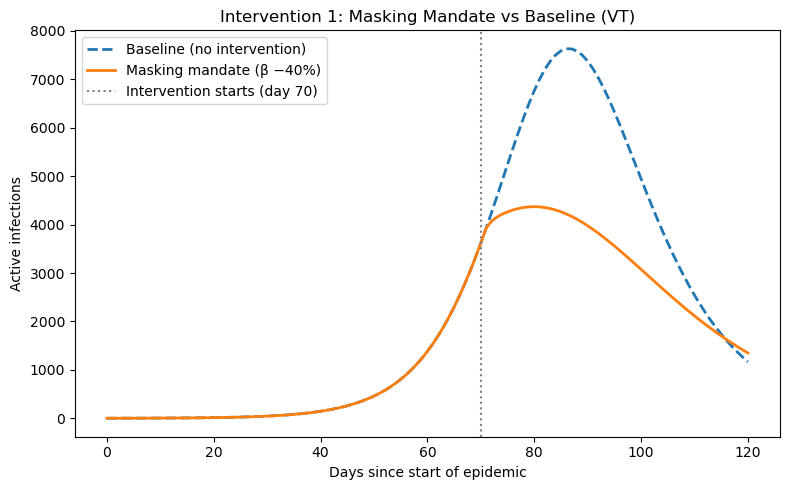

In [21]:
beta_mask = best_beta * (1 - 0.40)

S_mask, E_mask, I_mask, R_mask = run_two_phase(
    best_beta, best_sigma, best_gamma,
    beta_mask, best_sigma, best_gamma)

peak_base = np.max(I_base[70:])
peak_mask = np.max(I_mask[70:])

print("── Masking Mandate ──────────────────────────────────")
print(f"  Baseline peak infections (day 70–120):  {int(peak_base)}")
print(f"  Masking peak infections  (day 70–120):  {int(peak_mask)}")
print(f"  Peak cases reduced:                     {int(peak_base - peak_mask)}")
print(f"  Total cases prevented (day 70–120):     {int(np.sum(I_base[70:]) - np.sum(I_mask[70:]))}")

plt.figure(figsize=(8, 5))
plt.plot(t_full, I_base, label="Baseline (no intervention)", linewidth=2, linestyle="--")
plt.plot(t_full, I_mask, label="Masking mandate (β −40%)", linewidth=2)
plt.axvline(x=70, color="gray", linestyle=":", label="Intervention starts (day 70)")
plt.xlabel("Days since start of epidemic")
plt.ylabel("Active infections")
plt.title("Intervention 1: Masking Mandate vs Baseline (VT)")
plt.legend()
plt.tight_layout()
plt.show()

##### 2g.2b Vaccine Campaign


── Vaccine Campaign (single event) ──────────────────
  Baseline peak infections (day 70–120):  7629
  Vaccine peak infections  (day 70–120):  6903
  Peak cases reduced:                     725
  Total cases prevented (day 70–120):     18625


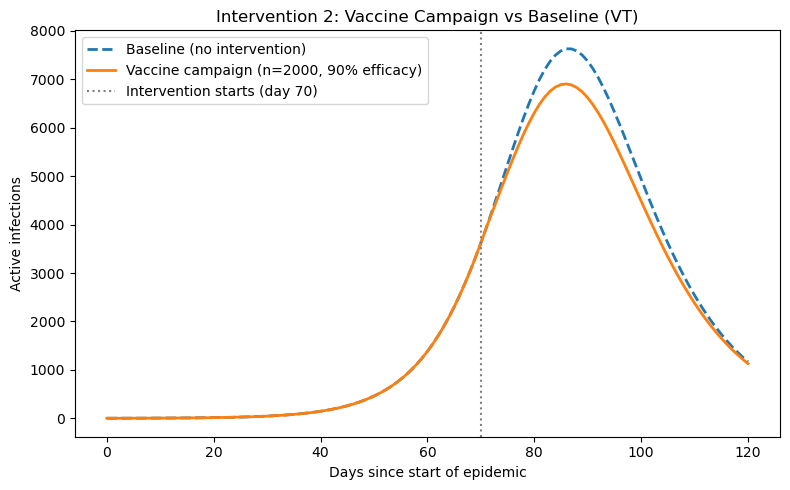

In [22]:
effective_vax = int(2000 * 0.90)  # 1800

# Run phase 1 to get state at day 70
S_pre, E_pre, I_pre, R_pre = euler_SEIR_custom(
    best_beta, best_sigma, best_gamma, t_pre,
    N_VT, S0_VT, E0_VT, I0_VT, R0_VT)

# Shift 1800 people from S to R at day 70
S_vax_start = max(S_pre[-1] - effective_vax, 0)
R_vax_start = R_pre[-1] + effective_vax

# Run phase 2 from adjusted day-70 state
S_vax2, E_vax2, I_vax2, R_vax2 = euler_SEIR_custom(
    best_beta, best_sigma, best_gamma, t_post,
    N_VT, S_vax_start, E_pre[-1], I_pre[-1], R_vax_start)

I_vax = np.concatenate([I_pre, I_vax2[1:]])
peak_vax = np.max(I_vax[70:])

print("\n── Vaccine Campaign (single event) ──────────────────")
print(f"  Baseline peak infections (day 70–120):  {int(peak_base)}")
print(f"  Vaccine peak infections  (day 70–120):  {int(peak_vax)}")
print(f"  Peak cases reduced:                     {int(peak_base - peak_vax)}")
print(f"  Total cases prevented (day 70–120):     {int(np.sum(I_base[70:]) - np.sum(I_vax[70:]))}")

plt.figure(figsize=(8, 5))
plt.plot(t_full, I_base, label="Baseline (no intervention)", linewidth=2, linestyle="--")
plt.plot(t_full, I_vax,  label="Vaccine campaign (n=2000, 90% efficacy)", linewidth=2)
plt.axvline(x=70, color="gray", linestyle=":", label="Intervention starts (day 70)")
plt.xlabel("Days since start of epidemic")
plt.ylabel("Active infections")
plt.title("Intervention 2: Vaccine Campaign vs Baseline (VT)")
plt.legend()
plt.tight_layout()
plt.show()

##### 2g.2c Testing & Quarentine


── Testing & Quarantine ─────────────────────────────
  Original infectious period:             8.8 days
  Reduced infectious period:              6.8 days
  Baseline peak infections (day 70–120):  7629
  Testing peak infections  (day 70–120):  5404
  Peak cases reduced:                     2225
  Total cases prevented (day 70–120):     75076


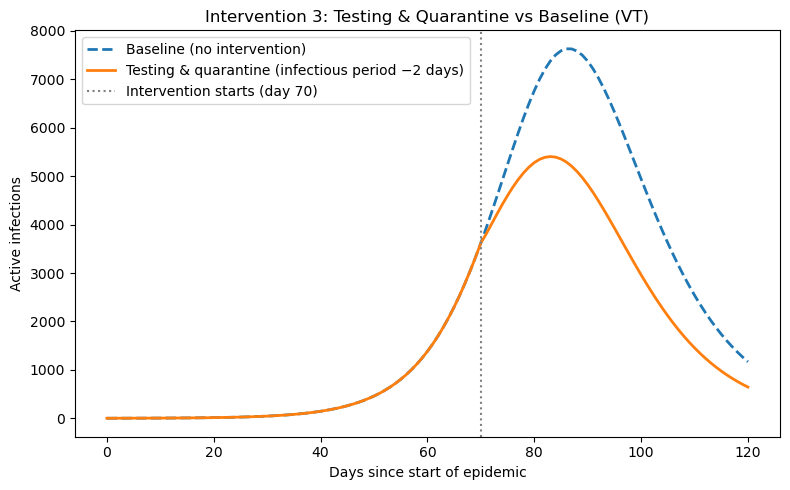

In [23]:
infectious_period_new = (1 / best_gamma) - 2
gamma_tq = 1 / infectious_period_new

S_tq, E_tq, I_tq, R_tq = run_two_phase(
    best_beta, best_sigma, best_gamma,
    best_beta, best_sigma, gamma_tq)

peak_tq = np.max(I_tq[70:])

print("\n── Testing & Quarantine ─────────────────────────────")
print(f"  Original infectious period:             {1/best_gamma:.1f} days")
print(f"  Reduced infectious period:              {infectious_period_new:.1f} days")
print(f"  Baseline peak infections (day 70–120):  {int(peak_base)}")
print(f"  Testing peak infections  (day 70–120):  {int(peak_tq)}")
print(f"  Peak cases reduced:                     {int(peak_base - peak_tq)}")
print(f"  Total cases prevented (day 70–120):     {int(np.sum(I_base[70:]) - np.sum(I_tq[70:]))}")

plt.figure(figsize=(8, 5))
plt.plot(t_full, I_base, label="Baseline (no intervention)", linewidth=2, linestyle="--")
plt.plot(t_full, I_tq,   label="Testing & quarantine (infectious period −2 days)", linewidth=2)
plt.axvline(x=70, color="gray", linestyle=":", label="Intervention starts (day 70)")
plt.xlabel("Days since start of epidemic")
plt.ylabel("Active infections")
plt.title("Intervention 3: Testing & Quarantine vs Baseline (VT)")
plt.legend()
plt.tight_layout()
plt.show()

## Verify and validate your analysis: 

*(Describe how you checked to see that your analysis gave you an answer that you believe (verify). Describe how your determined if your analysis gave you an answer that is supported by other evidence (e.g., a published paper).*

## Conclusions and Ethical Implications: 

> Intervention 1: Mask Mandates

Reducing the transmission rate (β) by 40% through a masking mandate significantly lowers the peak number of infections and flattens the epidemic curve. Although the outbreak still occurs, the peak is much smaller and spread out over a longer time. This suggests masking can be an effective strategy to reduce strain on healthcare systems by lowering the number of simultaneous infections.

> Intervention 2: Vaccine Campaign

The vaccination campaign reduces the peak number of infections slightly compared to the baseline. However, because the vaccine rollout occurs after the epidemic is already growing rapidly, the overall effect is smaller than expected. This shows that vaccination programs are most effective when implemented early in an outbreak.

> Intervention 3: Testing & Quarantine

Testing and quarantining shorten the infectious period, which reduces transmission and significantly lower the epidemic peak. Compared to the baseline scenario, the number of active infections decreases more quickly after the peak. This indicates that identifying and isolating infected individuals can be a powerful tool for controlling disease spread.

> Overall Conclusions

Based on the SEIR model and parameter optimization, the estimated epidemic parameters from the best fit model were β = 0.293, σ = 0.550, and γ = 0.114. The model predicted the epidemic peak at approximately day 80 with about 3692 active infections. When compared with the full dataset, the percent relative error was 12.1% for peak cases and 2.45% for peak day.

Among the tested interventions, the masking mandate and testing with quarantine were the most effective at reducing the peak number of infections. Therefore, early masking policies and strong testing and quarantine programs are recommended to reduce transmission and flatten the epidemic curve.

Based on the estimated parameters and the overall epidemic dynamics, the virus most closely resembles a respiratory virus such as those in the INSERT HERE family, which are characterized by moderate transmission rates and an incubation period before individuals become infectious.

Overall, while the model provides useful insight into epidemic behavior, prediction errors occur because the model assumes constant parameters and uniform mixing of the population, which may not fully represent real-world transmission patterns.

> Ethical Implications

Epidemiological models can influence important public health decisions such as masking policies, testing strategies, and vaccine distribution. Because these models rely on assumptions and imperfect data, it is important to communicate their uncertainties and limitations clearly so policymakers do not treat predictions as exact outcomes. Ethical considerations also include ensuring that interventions recommended by models are fair and do not disproportionately harm certain populations. Transparency in modeling and responsible use of predictions helps maintain public trust and supports informed decision-making during an outbreak.

## Limitations and Future Work: 

> Limitations

- The SEIR model assumes constant transmission (β), incubation (σ), and recovery (γ) rates, but these can change over time due to behavior or public health interventions.
- The model assumes everyone in the population mixes equally, which is not realistic because people interact in smaller social groups.
- The analysis relies on reported case data, which may include reporting delays, underreporting, or measurement errors.
- Initial conditions, such as the number of exposed individuals, were estimated and may not perfectly represent the true start of the outbreak.

> Future Work
- Incorporate time-varying parameters to better capture changes in transmission due to interventions or behavioral shifts.
- Use more detailed population data or contact networks to represent how people actually interact.
- Include additional data sources such as vaccination rates, testing rates, or mobility patterns.
- Update the model continuously with new data to improve prediction accuracy over time.